## Imports

In [ ]:
import os
import io

In [ ]:
from IPython.display import display
import ipywidgets as widgets

In [3]:
from PIL import Image

In [4]:
import torch
from torch import nn
import torchvision.transforms as transforms

## Configs

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
img_size = 224
seq_len = 3

In [7]:
feature_dim = 512
hidden_dim = 256
num_layers = 2
dropout = 0.3

In [8]:
class_names = ['BacterialBlights', 'Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow']
num_classes = len(class_names)

In [9]:
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

## Model

### SymNet

In [10]:
def conv_block(cin, cout, k=3, s=1, p=1):
    return nn.Sequential(
        nn.Conv2d(cin, cout, kernel_size=k, stride=s, padding=p, bias=False),
        nn.BatchNorm2d(cout),
        nn.ReLU(inplace=True),
    )

In [11]:
class SymNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 32),
            nn.MaxPool2d(2),
        )
        self.stage2 = nn.Sequential(
            conv_block(32, 64),
            conv_block(64, 64),
            nn.MaxPool2d(2),
        )
        self.stage3 = nn.Sequential(
            conv_block(64, 128),
            conv_block(128, 128),
            nn.MaxPool2d(2),
        )
        self.stage4 = nn.Sequential(
            conv_block(128, 256),
            conv_block(256, 256),
            nn.MaxPool2d(2),
        )
        self.stage5 = nn.Sequential(
            conv_block(256, 512),
            conv_block(512, 512),
            nn.AdaptiveAvgPool2d(1),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.stage5(x)
        return x.view(x.size(0), -1) 

### ProgNet

In [12]:
class ProgNet(nn.Module):
    def __init__(self, feature_dim=feature_dim, hidden_dim=hidden_dim, num_layers=num_layers,
                 num_classes=num_classes, dropout=dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, num_classes)
        )

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        last_hidden = torch.cat((hn[-2], hn[-1]), dim=1)
        return self.fc(last_hidden)

### CaneSight

In [13]:
class CaneSight(nn.Module):
    def __init__(self, symnet, prognet):
        super().__init__()
        self.symnet = symnet
        self.prognet = prognet

    def forward(self, x_seq):
        batch_size, seq_len, C, H, W = x_seq.size()
        features = []

        for t in range(seq_len):
            img = x_seq[:, t, :, :, :]
            feat = self.symnet(img)
            features.append(feat)

        features = torch.stack(features, dim=1)
        return self.prognet(features)

## Saved Model

In [14]:
model_name = "main"
folder_name = "Main"
model_dir = os.path.join("..", f"Saved_Models\\{folder_name}")
model_path = os.path.join(model_dir, "cane_sight_final.pth")
model_path

'..\\Saved_Models\\Main\\cane_sight_final.pth'

In [15]:
symnet = SymNet()
prognet = ProgNet(num_classes=num_classes, dropout=dropout)
model = CaneSight(symnet, prognet).to(device)

In [16]:
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

CaneSight(
  (symnet): SymNet(
    (stem): Sequential(
      (0): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (1): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (stage2): Sequential(
      (0): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (1): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

## Prediction Function

In [17]:
def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img)
    img_seq = img_tensor.unsqueeze(0).repeat(seq_len, 1, 1, 1)
    img_seq = img_seq.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_seq)
        probs = torch.softmax(output, dim=1)
        pred_idx = probs.argmax(dim=1).item()
        confidence = probs[0, pred_idx].item()

    print(f"Predicted Class: {class_names[pred_idx]}")
    print(f"Confidence: {confidence:.4f}")
    return class_names[pred_idx], confidence

## Image Upload and Prediction

FileUpload(value=(), accept='image/*', description='Upload')

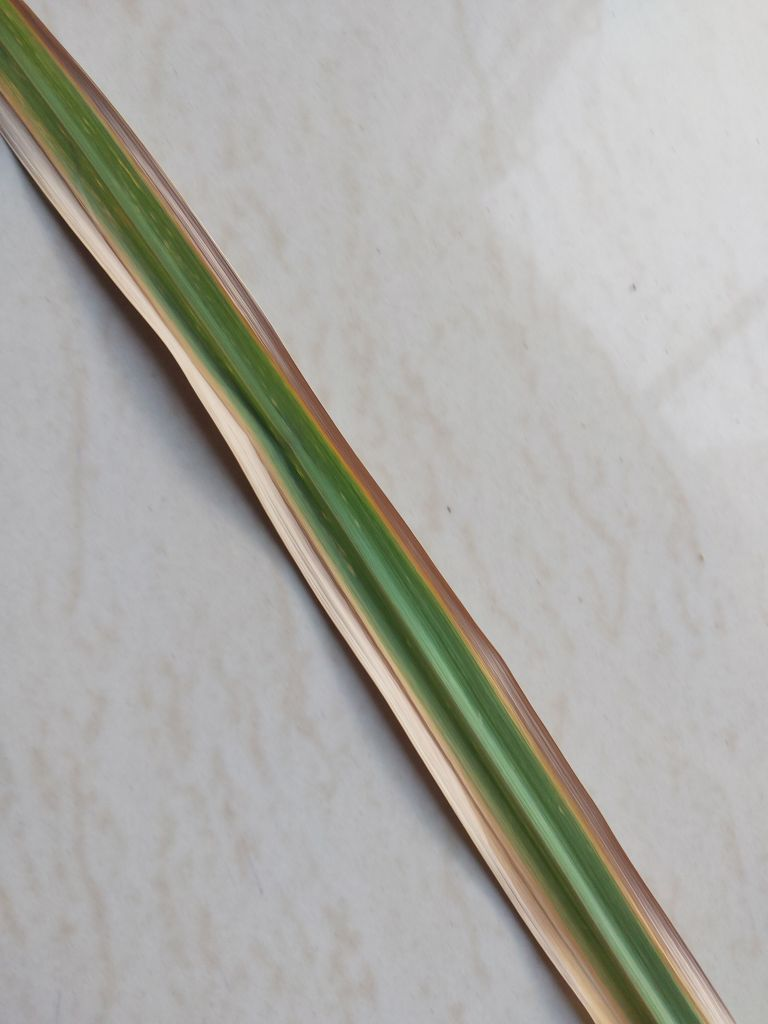

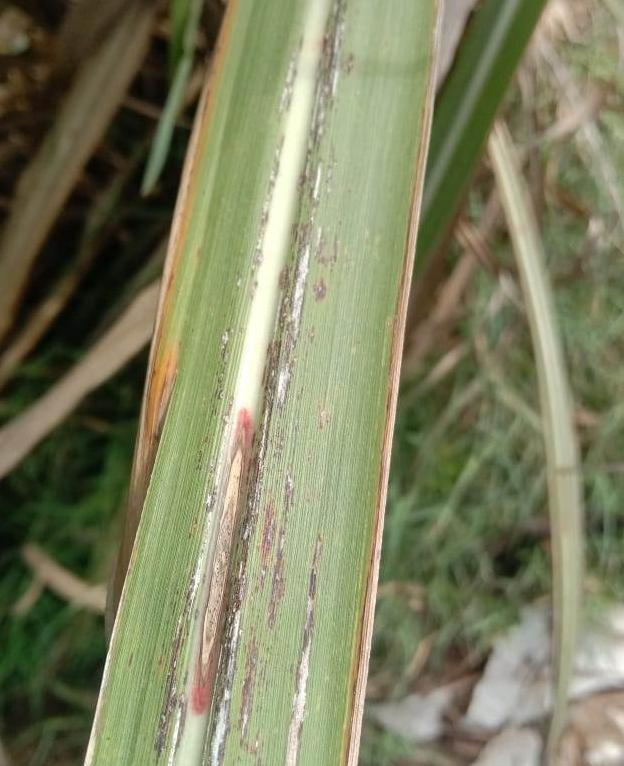

In [30]:
upload_dir = "image_uploads"
os.makedirs(upload_dir, exist_ok=True)

uploader = widgets.FileUpload(
    accept='image/*',
    multiple=False  
)
display(uploader)

def on_upload_change(change):
    print("Upload event triggered!")
    value = uploader.value
    if isinstance(value, dict):
        files = value.items()
    else:
        files = [(f['name'], f) for f in value]
    
    for filename, fileinfo in files:
        img = Image.open(io.BytesIO(fileinfo['content'])).convert("RGB")
        save_path = os.path.join(upload_dir, filename)
        img.save(save_path)
        display(img)

uploader.observe(on_upload_change, names='value')

In [32]:
latest = sorted(os.listdir("image_uploads"), key=lambda x: os.path.getmtime(os.path.join("image_uploads", x)))[-1]
img_path = os.path.join("image_uploads", latest)

print("Running prediction on:", img_path)
predict_image(img_path)

Running prediction on: image_uploads\cropped_rust (2).jpeg
Predicted Class: Rust
Confidence: 0.9606


('Rust', 0.9606242179870605)